In [1]:
import os
import folium

import geopandas as gpd
from main import OutputFormat
import json
from client import AnthropicClient
from main import DataProcessor, Agent
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("ANTHROPIC_API_KEY")
if api_key is None:
    raise ValueError("ANTHROPIC_API_KEY not found in environment variables")


In [2]:
processor = DataProcessor("data.json")
analysis_data = processor.load_data()
client = AnthropicClient(api_key)
agent = Agent(client, processor)

In [3]:
outputs: list[OutputFormat] = []
for item in analysis_data:
    outputs.append(agent.run(item))

In [4]:
for n in outputs:
    print(n.document_type)
    print(n.confidence)
    print(n.comments)
    print(n.location)

map
4
This is a planning layout map for a battery energy storage system (BESS) project called 'Chickerell' by 23 Energy. The map shows detailed topographic survey data with spot heights, vegetation descriptions (hedgelines, trees, copses), fencing types, and infrastructure including Tesla Megapack units, 2500 KVA transformers, 25 MVA transformers, customer substation, acoustic fencing, CCTV mast, vehicle turning areas, and swept path analysis for a Liebherr LTM 1090-4.2 mobile crane. Prepared by Corylus Planning & Environmental Ltd based in Yanworth, Cheltenham, Gloucestershire. Drawing reference CH/538/02 Rev D dated 13-10-22 at 1:500 scale on A3.
easting=364000 northing=80500
report
4
Archaeological Desk-Based Assessment for a proposed grid-scale battery storage facility on land at Chickerell, Weymouth, Dorset. Prepared by Avalon Planning & Heritage for client 23 Energy (project number A2465). The assessment found several foci of Roman and Medieval archaeological activity within 1km,

In [5]:
processor.get_pdf_content("./data/doc_a.pdf")


'41.22\nS\nMature\nHedgeline 7\n4\nm\n0.\nh\n64\n40.\n4\n9\n0\n5\n.62\n40.95\n41.06\n41.15\n41.04\n40.9\n4\n2\n1.17\n41.03\n41.09\nA 40.51 40.82\nG 40.09 40.69\n40.16 40.66 40.62\n40.47\n39.96 40.32 Sapling\nEave Ht Stables 40.14 40.26\nExtent of Canopy 39.15 39.41 39.54 39.78 40.04 39.97 40.05 43.12 Conc. 40.05 40.05 39.96 40.10 40.10 40.02 G A S 36.99 37. 3 3 7 7 .24 36.83 37.26 37.63 Mature H 3 e 8 d . g 0 e 0 line 7mh 38.2 3 6 8 3 . 8 4 . 5 31 38.69 39.0 3 2 3 8 8 . . 7 8 0 0 Wire-link & Rail 1. 3 2 9 m 3 . 8 2 h . 2 88 39 3 . 9 2 . 7 0 3 3 9 9 . . 0 6 9 4 3 3 9 9 . . 4 1 6 9 39.76 39.58 40 3 .0 9 0 .48 40.03 39.54 3 3 3 9 9 9 . . 7 5 .2 0 5 5 40.03 39.73 39.12 39.83 39.41 39.32 38.9 3 3 9.71 Wire-link 1.1mh 38.91\n39.0\nG A\nS Mixed Hedgeline\n3 6\n5\n.\nm\n6\nh\n3 36.\n3\n7\n7\n3\n.15 37.15\n37.18\n38.75\n38.50\n39.24 39.07 38.87 3\n3\n8\n8\n.7\n.5\n5\n0\n38.75 38.63 38.45 38.54\nWillows 7mh 36.24 36.34 36.68 37.08 37.56 37.81 38.15 38.33 38.49 38.59 38.54 38.51 38.3 3 9 8.25 38.

In [6]:
actual = analysis_data[0].eval_location

In [7]:
features = []
for n in outputs:
    if n.location is not None:
        features.append({
            "type": "Feature",
            "geometry": {
                "type": "Point",
                "coordinates": [n.location.easting, n.location.northing],
            },
            "properties": {
                "document_type": n.document_type,
                "confidence": n.confidence,
                "comments": n.comments,
            },
        })
geojson = {
    "type": "FeatureCollection",
    "features": features,
}


In [17]:
features.append({
    "type": "Feature",
    "geometry": {
        "type": "Point",
        "coordinates": [actual.easting, actual.northing],
    },
    "properties": {
        "document_type": "Actual Location",
        "confidence": 1.0,
        "comments": "",
    },
})
points = gpd.GeoDataFrame.from_features(geojson, crs="EPSG:27700") # type: ignore
points.to_crs(epsg=4326, inplace=True)


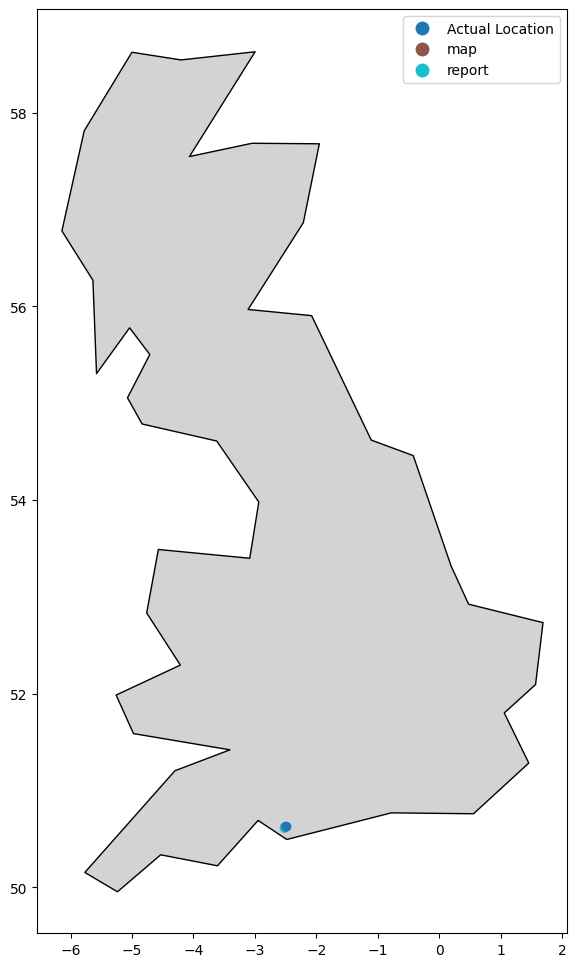

In [23]:
import geodatasets
import matplotlib.pyplot as plt                                                                                                                                                               
world = gpd.read_file(geodatasets.get_path("naturalearth.land"))
uk = world.cx[-8:-5, 50:51]  # clip to UK bounding box

fig, ax = plt.subplots(figsize=(8, 12))
uk.plot(color="lightgrey", edgecolor="black", ax=ax)
points.plot(column="document_type", categorical=True, legend=True, ax=ax)
plt.show()
